# Tech Salary Analysis

## Project Introduction

This project analyzes global technology salary data to understand how different factors affect salaries in the tech industry.

The analysis focuses on job titles, remote work ratio, and company size to identify salary trends and provide useful insights for HR consulting and compensation decisions.

## Business Background

As part of an HR consulting scenario, the goal is to help companies understand salary trends in the competitive technology industry.

By analyzing salary data, companies can make better compensation decisions and offer competitive salary packages to attract and retain top talent.

## Objectives

- Load and explore the salary dataset
- Check dataset information and missing values
- Identify the top 5 job titles with the highest average salary in USD
- Compare average salaries by remote work ratio
- Analyze salary distribution across company sizes
- Create visualizations
- Write clear insights from the analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"C:\Users\t102030\OneDrive\سطح المكتب\Data-Science-Portfolio\tech-salary-analysis\salaries.csv")

df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,MI,FT,Developer,168276,USD,168276,US,0,US,M
1,2024,MI,FT,Developer,112184,USD,112184,US,0,US,M
2,2024,EN,FT,Developer,180000,USD,180000,US,0,US,M
3,2024,EN,FT,Developer,133500,USD,133500,US,0,US,M
4,2024,EN,FT,Developer,122000,USD,122000,US,0,US,M


## Dataset Overview

The dataset contains salary information for employees in the technology industry across different countries.

It includes columns such as work year, experience level, employment type, job title, salary, salary currency, salary in USD, employee residence, remote work ratio, company location, and company size.

This dataset will be used to analyze salary trends and answer the challenge questions.

In [7]:
df.shape


(57194, 11)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57194 entries, 0 to 57193
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           57194 non-null  int64 
 1   experience_level    57194 non-null  object
 2   employment_type     57194 non-null  object
 3   job_title           57194 non-null  object
 4   salary              57194 non-null  int64 
 5   salary_currency     57194 non-null  object
 6   salary_in_usd       57194 non-null  int64 
 7   employee_residence  57194 non-null  object
 8   remote_ratio        57194 non-null  int64 
 9   company_location    57194 non-null  object
 10  company_size        57194 non-null  object
dtypes: int64(4), object(7)
memory usage: 4.8+ MB


In [9]:
df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

## Checking Dataset Information

In this step, we checked the dataset size, column information, data types, and missing values.

This helps us understand the structure and quality of the dataset before starting the analysis.

In [11]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,MI,FT,Developer,168276,USD,168276,US,0,US,M
1,2024,MI,FT,Developer,112184,USD,112184,US,0,US,M
2,2024,EN,FT,Developer,180000,USD,180000,US,0,US,M
3,2024,EN,FT,Developer,133500,USD,133500,US,0,US,M
4,2024,EN,FT,Developer,122000,USD,122000,US,0,US,M


In [12]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,57194.000000,5.719400e+04,57194.000000,57194.000000
mean,2023.776305,1.641818e+05,159223.565829,22.211246
std,0.519883,2.060327e+05,72155.164297,41.424262
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.094000e+05,109300.000000,0.000000
50%,2024.000000,1.495520e+05,149040.000000,0.000000
75%,2024.000000,2.000000e+05,200000.000000,0.000000
max,2024.000000,3.040000e+07,800000.000000,100.000000


In [13]:
df["remote_ratio"].value_counts()

0      44355
100    12568
50       271
Name: remote_ratio, dtype: int64

In [14]:
df["company_size"].value_counts()

M    55025
L     1965
S      204
Name: company_size, dtype: int64

## Data Exploration

In this step, we explored the dataset by reviewing the first rows, summary statistics, remote work values, and company size values.

This helps us understand the main variables that will be used in the analysis.

## Top 5 Job Titles by Average Salary

In this step, we analyze the top 5 job titles with the highest average salary in USD.

This helps identify which technology roles are associated with the highest compensation.

In [15]:
top_5_jobs = df.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False).head(5)

top_5_jobs

job_title
Analytics Engineering Manager    399880.000000
Data Science Tech Lead           375000.000000
Applied AI ML Lead               292500.000000
Head of Machine Learning         288701.000000
Engineering Manager              262525.615672
Name: salary_in_usd, dtype: float64

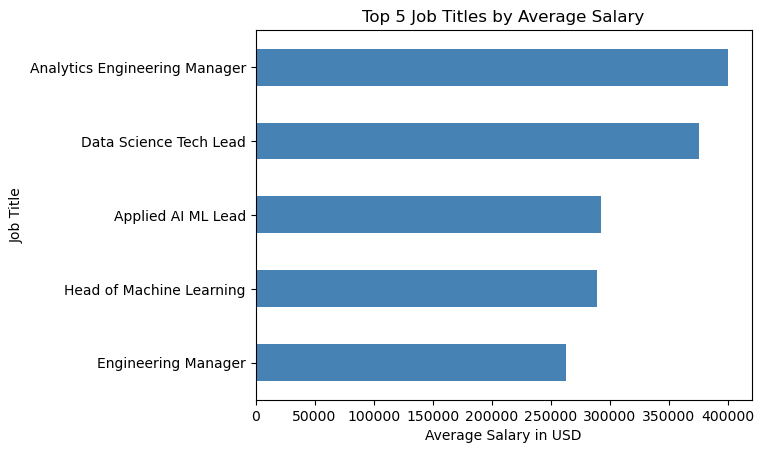

In [16]:
top_5_jobs.plot(kind="barh", color="steelblue")

plt.title("Top 5 Job Titles by Average Salary")
plt.xlabel("Average Salary in USD")
plt.ylabel("Job Title")
plt.gca().invert_yaxis()
plt.show()

## Average Salary by Remote Work Ratio

In this step, we compare the average salaries of employees based on their remote work ratio.

The remote work ratio represents how much of the work is done remotely:
- 0 means no remote work
- 50 means partially remote or hybrid
- 100 means fully remote

This helps us understand whether remote work is associated with higher or lower average salaries.

In [17]:
remote_salary = df.groupby("remote_ratio")["salary_in_usd"].mean().sort_index()

remote_salary

remote_ratio
0      162401.766836
50      81866.867159
100    149675.074395
Name: salary_in_usd, dtype: float64

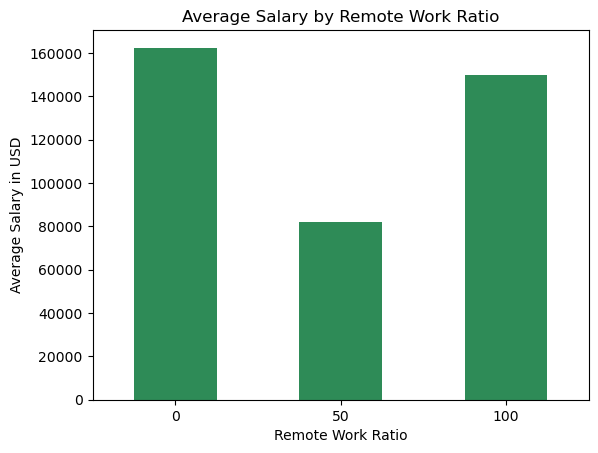

In [18]:
remote_salary.plot(kind="bar", color="seagreen")

plt.title("Average Salary by Remote Work Ratio")
plt.xlabel("Remote Work Ratio")
plt.ylabel("Average Salary in USD")
plt.xticks(rotation=0)
plt.show()

## Salary Analysis by Company Size

In this step, we analyze salaries across different company sizes.

Company size is represented as:
- S: Small company
- M: Medium company
- L: Large company

This analysis helps identify which company size offers the highest average salary and how salaries are distributed across company sizes.

In [19]:
company_size_salary = df.groupby("company_size")["salary_in_usd"].mean().sort_values(ascending=False)

company_size_salary

company_size
M    159724.759782
L    152617.140967
S     87671.740196
Name: salary_in_usd, dtype: float64

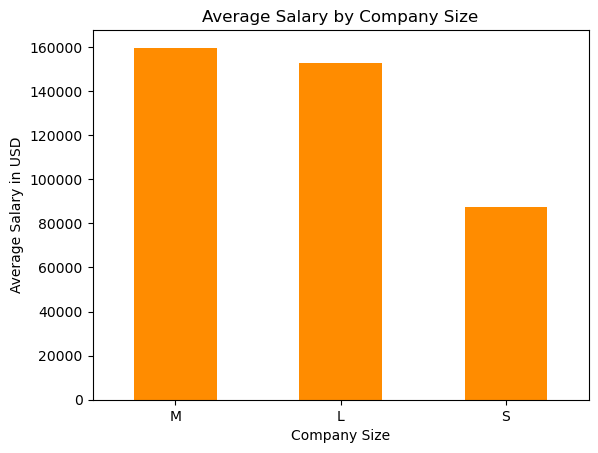

In [20]:
company_size_salary.plot(kind="bar", color="darkorange")

plt.title("Average Salary by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Average Salary in USD")
plt.xticks(rotation=0)
plt.show()

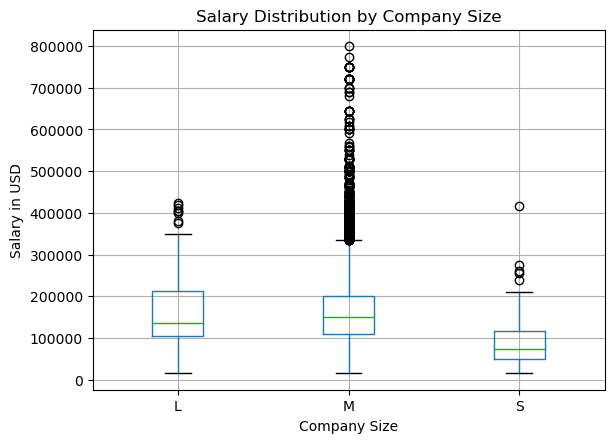

In [21]:
df.boxplot(column="salary_in_usd", by="company_size")

plt.title("Salary Distribution by Company Size")
plt.suptitle("")
plt.xlabel("Company Size")
plt.ylabel("Salary in USD")
plt.show()

## Salary Distribution by Company Size Insight

The box plot shows that medium-sized companies have a wide salary distribution and many high salary outliers.

Large companies also offer relatively high salaries, while small companies generally show lower salary ranges compared to medium and large companies.

Overall, medium-sized companies appear to have the highest salary variation and some of the highest salary values in the dataset.

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [23]:
top_job = top_5_jobs.idxmax()
top_job_salary = top_5_jobs.max()

top_remote_ratio = remote_salary.idxmax()
top_remote_salary = remote_salary.max()

top_company_size = company_size_salary.idxmax()
top_company_salary = company_size_salary.max()

print("Top job title by average salary:", top_job)
print("Average salary:", round(top_job_salary, 2))
print()

print("Remote ratio with highest average salary:", top_remote_ratio)
print("Average salary:", round(top_remote_salary, 2))
print()

print("Company size with highest average salary:", top_company_size)
print("Average salary:", round(top_company_salary, 2))

Top job title by average salary: Analytics Engineering Manager
Average salary: 399880.0

Remote ratio with highest average salary: 0
Average salary: 162401.77

Company size with highest average salary: M
Average salary: 159724.76


## Average Salary by Experience Level

In this step, we analyze the average salary by experience level.

This helps us understand how salary changes as employees gain more experience.

In [24]:
experience_salary = df.groupby("experience_level")["salary_in_usd"].mean().sort_values(ascending=False)

experience_salary

experience_level
EX    202286.017559
SE    173846.536276
MI    143832.928698
EN    104454.252054
Name: salary_in_usd, dtype: float64

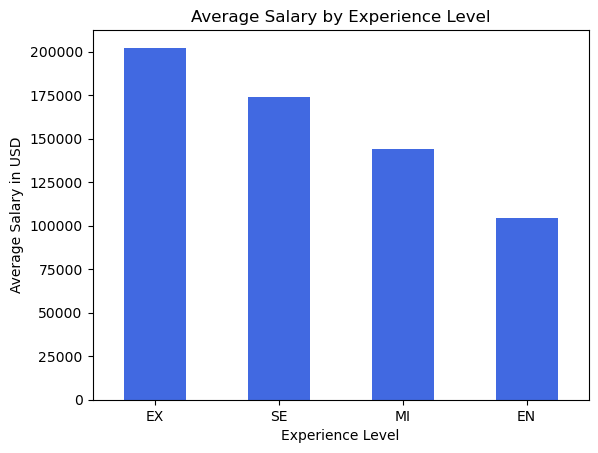

In [25]:
experience_salary.plot(kind="bar", color="royalblue")

plt.title("Average Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary in USD")
plt.xticks(rotation=0)
plt.show()

## Top 10 Most Common Job Titles

In this step, we analyze the most common job titles in the dataset.

This helps us understand which technology roles appear most frequently in the salary data.

In [26]:
top_job_counts = df["job_title"].value_counts().head(10)

top_job_counts

Data Scientist               9706
Data Engineer                7970
Data Analyst                 5980
Software Engineer            5817
Machine Learning Engineer    5067
Engineer                     2482
Research Scientist           1961
Manager                      1556
Applied Scientist            1380
Data Architect               1073
Name: job_title, dtype: int64

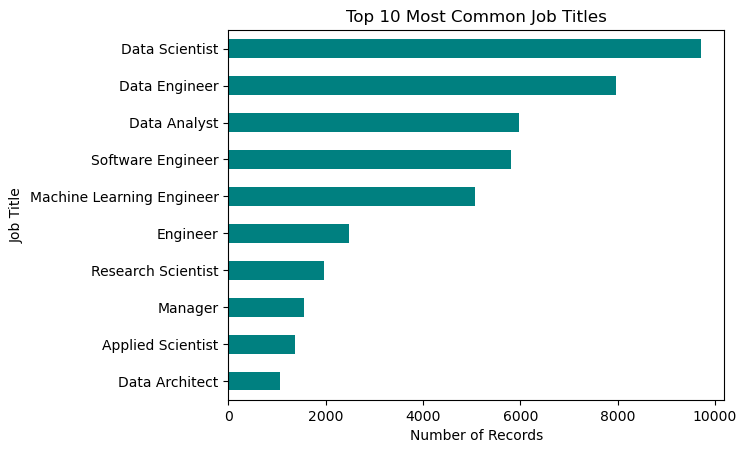

In [27]:
top_job_counts.plot(kind="barh", color="teal")

plt.title("Top 10 Most Common Job Titles")
plt.xlabel("Number of Records")
plt.ylabel("Job Title")
plt.gca().invert_yaxis()
plt.show()

## Average Salary by Work Year

In this step, we analyze the average salary by work year.

This helps us understand how average salaries changed over time.

In [28]:
salary_by_year = df.groupby("work_year")["salary_in_usd"].mean().sort_index()

salary_by_year

work_year
2020    102250.866667
2021     99922.073394
2022    134183.903556
2023    153700.755456
2024    161488.267616
Name: salary_in_usd, dtype: float64

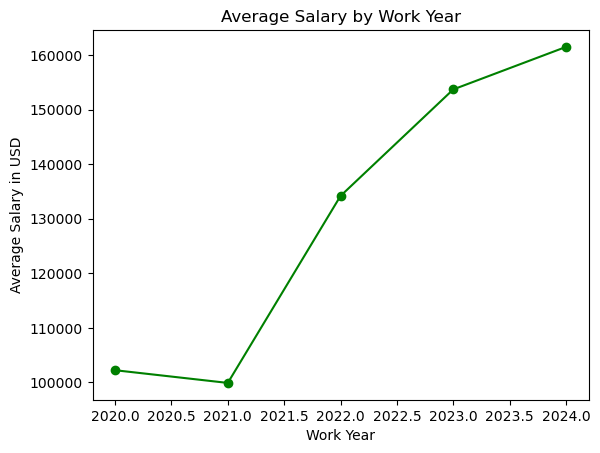

In [29]:
salary_by_year.plot(kind="line", marker="o", color="green")

plt.title("Average Salary by Work Year")
plt.xlabel("Work Year")
plt.ylabel("Average Salary in USD")
plt.show()

## Conclusion

This project analyzed global technology salary data to understand how different factors affect salaries in the tech industry.

The analysis answered the main challenge questions by identifying the top 5 job titles with the highest average salary, comparing salaries across remote work ratios, and analyzing salary distribution by company size.

Additional analysis was also performed to explore salary differences by experience level, identify the most common job titles, and understand how average salaries changed over time.

## Key Insights

- Some job titles have significantly higher average salaries than others.
- Remote work ratio shows differences in average salary levels.
- Medium-sized companies show a wide salary distribution and many high salary outliers.
- Experience level has a clear impact on average salary.
- Some job titles appear more frequently in the dataset than others.
- Average salaries changed across different work years.
- Salary insights can help companies make better compensation decisions and stay competitive in hiring.

## Tools Used

- Python
- Pandas
- Matplotlib
- Jupyter Notebook